# Inspect Trained Policy: A2C Returns Model

Load the best model from `A2C_returns_20251030_110653` and analyze:
- Policy behavior on training data
- Policy behavior on evaluation data
- Action distribution
- Value function estimates
- Trading decisions vs market conditions

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from stable_baselines3 import A2C
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

from rl_trading_lab.environment import TradingEnv

# Set style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

## 1. Load the Best Model

In [2]:
# Path to your trained model
checkpoint_name = "A2C_returns_20251030_110653"
model_path = Path(f"../checkpoints/{checkpoint_name}/best_model/best_model.zip")
vecnormalize_path = Path(f"../checkpoints/{checkpoint_name}/best_model/vecnormalize.pkl")

print(f"Loading model from: {checkpoint_name}")
print(f"Model exists: {model_path.exists()}")
print(f"VecNormalize exists: {vecnormalize_path.exists()}")

if not model_path.exists():
    print(f"\n❌ ERROR: Model not found at {model_path}")
    print("Available checkpoints:")
    for p in Path("../checkpoints").glob("*/best_model/best_model.zip"):
        print(f"  - {p.parent.parent.name}")
    raise FileNotFoundError(f"Model not found: {model_path}")

# Load the model
model = A2C.load(model_path)
print(f"\n✓ Model loaded: {model.__class__.__name__}")
print(f"  Learning rate: {model.learning_rate}")
print(f"  n_steps: {model.n_steps}")

Loading model from: A2C_returns_20251030_110653
Model exists: True
VecNormalize exists: True

✓ Model loaded: A2C
  Learning rate: 0.0001
  n_steps: 5


## 2. Load Data and Create Environments

In [3]:
# Load your data (from config)
data_path = "../../tools/examples/btcusdt_fractional_indicators.parquet"
df = pd.read_parquet(data_path)

print(f"Data loaded from: {data_path}")
print(f"Data shape: {df.shape}")
if 'timestamp' in df.columns:
    print(f"Date range: {df['timestamp'].iloc[0]} to {df['timestamp'].iloc[-1]}")
print(f"\nFirst 10 columns: {df.columns.tolist()[:10]}")

# Split data (matches config: val_split=0.2, test_split=0.1)
val_split = 0.2
test_split = 0.1

n = len(df)
train_end = int(n * (1 - val_split - test_split))
val_end = int(n * (1 - test_split))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"\nData splits (matching training config):")
print(f"  Train: {len(train_df)} bars ({len(train_df)/n*100:.1f}%)")
print(f"  Val:   {len(val_df)} bars ({len(val_df)/n*100:.1f}%)")
print(f"  Test:  {len(test_df)} bars ({len(test_df)/n*100:.1f}%)")

Data loaded from: ../../tools/examples/btcusdt_fractional_indicators.parquet
Data shape: (56663, 14)
Date range: 2025-10-06 00:01:10.015000 to 2025-10-25 09:44:59.116000

First 10 columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'ratio_sma_5_close', 'ratio_sma_20_close', 'ratio_range_close', 'fracdiff_0.4']

Data splits (matching training config):
  Train: 39664 bars (70.0%)
  Val:   11332 bars (20.0%)
  Test:  5667 bars (10.0%)


In [4]:
# Select features for observations (from observation/default.yaml config)
feature_cols = [
    "ratio_sma_5_close_zscore",
    "ratio_sma_20_close_zscore",
    "ratio_range_close_zscore",
    "fracdiff_0.4_zscore",
]

# Verify features exist
missing_features = [f for f in feature_cols if f not in df.columns]
if missing_features:
    print(f"❌ ERROR: Missing features: {missing_features}")
    print(f"Available columns: {df.columns.tolist()}")
    raise ValueError(f"Missing required features: {missing_features}")

print(f"✓ Using {len(feature_cols)} observation features (from config):")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i}. {f}")

# Create environment function (matching env/default.yaml config)
def create_env(df, one_trade_mode=True):
    """Create a trading environment matching training config."""
    env = TradingEnv(
        df=df,
        lookback_window=20,  # From env config
        initial_balance=10000,  # From env config
        commission_rate=0.00,  # From env config
        slippage_rate=0.000,  # From env config
        reward_type='returns',  # From env config
        discrete_actions=True,  # From env config
        max_position_pct=0.95,  # From env config
        features_to_use=feature_cols,
        randomize_start=True,  # False for evaluation
        min_episode_length=100,  # From env config
        min_holding_period=5,  # From env config
        hold_closes_position=True,  # From env config
        price_column='close',  # From env config
        one_trade_mode=one_trade_mode,
    )
    return env

# Create environments
train_env = create_env(train_df, one_trade_mode=True)
val_env = create_env(val_df, one_trade_mode=True)

print(f"\n✓ Environments created")
print(f"  Action space: {train_env.action_space}")
print(f"  Observation space: {train_env.observation_space.shape}")

✓ Using 4 observation features (from config):
  1. ratio_sma_5_close_zscore
  2. ratio_sma_20_close_zscore
  3. ratio_range_close_zscore
  4. fracdiff_0.4_zscore

✓ Environments created
  Action space: Discrete(3)
  Observation space: (87,)


## 3. Load VecNormalize Stats

In [5]:
# Wrap environments
train_vec_env = DummyVecEnv([lambda: train_env])
val_vec_env = DummyVecEnv([lambda: val_env])

# Load VecNormalize if it was used
if vecnormalize_path.exists():
    print("Loading VecNormalize statistics...")
    train_vec_env = VecNormalize.load(vecnormalize_path, train_vec_env)
    val_vec_env = VecNormalize.load(vecnormalize_path, val_vec_env)
    
    # Important: Disable training mode for evaluation
    train_vec_env.training = False
    train_vec_env.norm_reward = False
    val_vec_env.training = False
    val_vec_env.norm_reward = False
    
    print("✓ VecNormalize loaded and configured for evaluation")
else:
    print("⚠ No VecNormalize found - using raw observations")

Loading VecNormalize statistics...
✓ VecNormalize loaded and configured for evaluation


## 4. Rollout Policy on Training Data

In [6]:
def rollout_policy(env, model, n_episodes=10, deterministic=True):
    """Rollout policy and collect statistics."""
    import warnings
    
    all_actions = []
    all_values = []
    all_rewards = []
    all_positions = []
    all_prices = []
    episode_returns = []
    
    for ep in range(n_episodes):
        obs = env.reset()
        done = False
        ep_reward = 0
        
        ep_actions = []
        ep_values = []
        ep_rewards = []
        ep_positions = []
        ep_prices = []
        
        while not done:
            # Get action and value estimate
            action, _states = model.predict(obs, deterministic=deterministic)
            
            # Get value function estimate
            with warnings.catch_warnings():
                warnings.filterwarnings('ignore')
                value = model.policy.predict_values(model.policy.obs_to_tensor(obs)[0])
                value = value.detach().cpu().numpy().flatten()[0]
            
            # Take action
            obs, reward, done, info = env.step(action)
            
            # Get underlying env for trading info
            # Handle both VecEnv wrapper and raw env
            if hasattr(env, 'envs'):
                trading_env = env.envs[0]
            else:
                trading_env = env
            
            # Safely extract position and price
            position_size = trading_env.portfolio.position.size
            current_price = trading_env._get_current_price()
            
            ep_actions.append(action[0])
            ep_values.append(value)
            ep_rewards.append(reward[0])
            ep_positions.append(position_size)
            ep_prices.append(current_price)
            ep_reward += reward[0]
            
            if done[0]:
                break
        
        all_actions.extend(ep_actions)
        all_values.extend(ep_values)
        all_rewards.extend(ep_rewards)
        all_positions.extend(ep_positions)
        all_prices.extend(ep_prices)
        episode_returns.append(ep_reward)
        
        print(f"Episode {ep+1}: {len(ep_actions)} steps, return={ep_reward:.4f}")
    
    return {
        'actions': np.array(all_actions),
        'values': np.array(all_values),
        'rewards': np.array(all_rewards),
        'positions': np.array(all_positions),
        'prices': np.array(all_prices),
        'episode_returns': np.array(episode_returns)
    }

print("\n=== Training Data Rollout ===")
train_results = rollout_policy(train_vec_env, model, n_episodes=10)


=== Training Data Rollout ===
Episode 1: 6 steps, return=-0.0002
Episode 2: 14 steps, return=-0.0025
Episode 3: 1623 steps, return=0.0327
Episode 4: 3 steps, return=0.0005
Episode 5: 56 steps, return=0.0027
Episode 6: 4 steps, return=0.0003
Episode 7: 7 steps, return=-0.0018
Episode 8: 6 steps, return=0.0007
Episode 9: 199 steps, return=-0.0054
Episode 10: 56 steps, return=-0.0035


## 5. Analyze Action Distribution

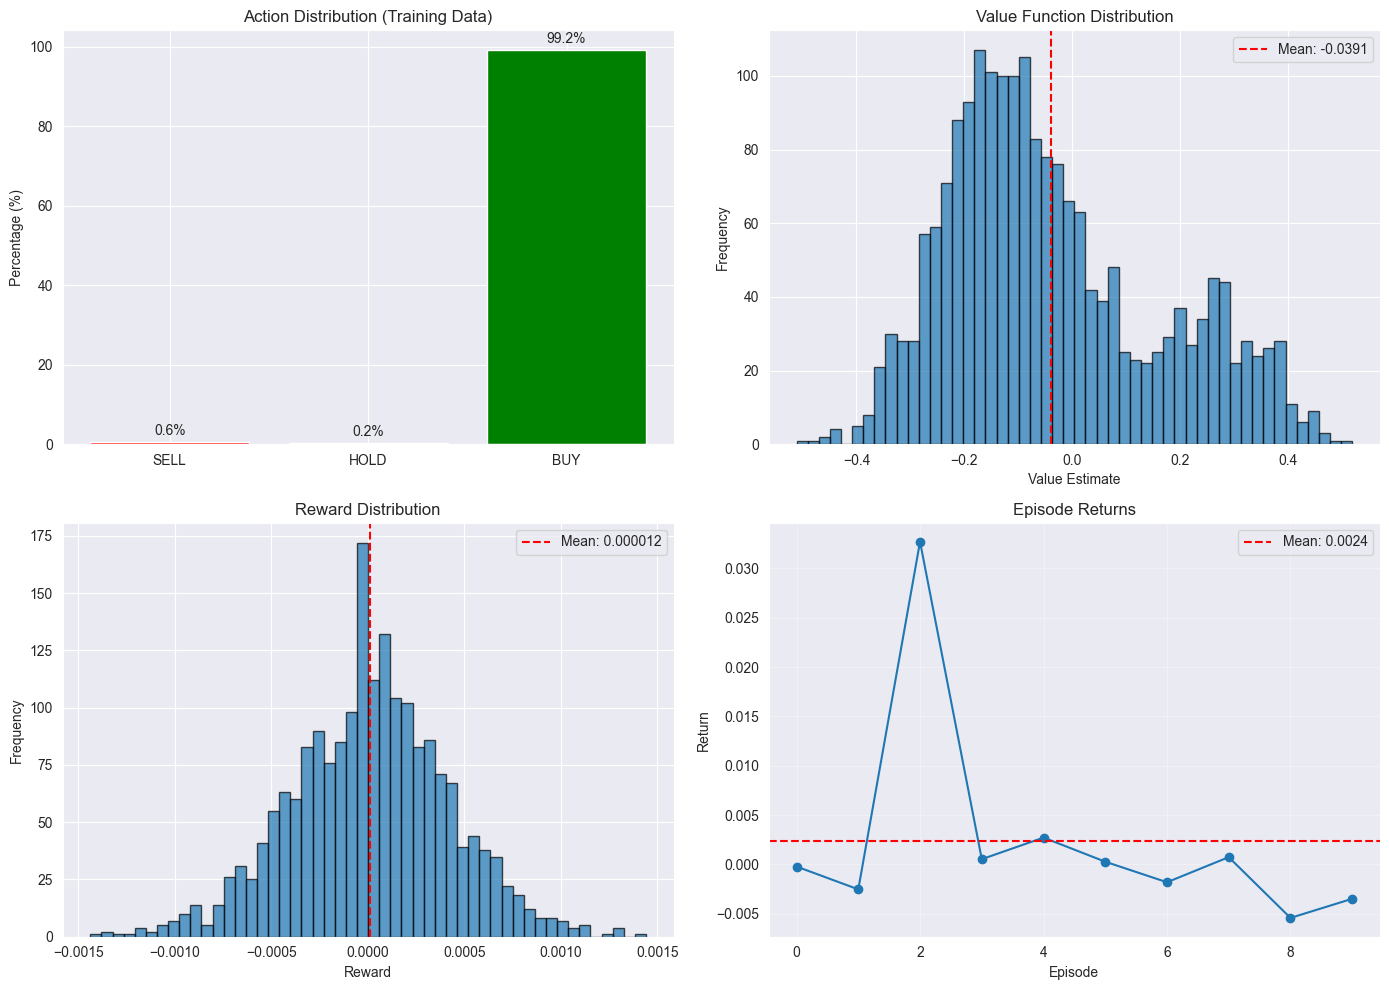


Summary Statistics (Training):
  Mean episode return: 0.0024
  Std episode return: 0.0104
  Mean value estimate: -0.0391
  Mean reward: 0.000012


In [7]:
action_names = ['SELL', 'HOLD', 'BUY']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Action distribution
ax = axes[0, 0]
action_counts = np.bincount(train_results['actions'], minlength=3)
action_pcts = action_counts / action_counts.sum() * 100
bars = ax.bar(action_names, action_pcts, color=['red', 'gray', 'green'])
ax.set_ylabel('Percentage (%)')
ax.set_title('Action Distribution (Training Data)')
for i, (bar, pct) in enumerate(zip(bars, action_pcts)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{pct:.1f}%', ha='center', va='bottom')

# Value function distribution
ax = axes[0, 1]
ax.hist(train_results['values'], bins=50, alpha=0.7, edgecolor='black')
ax.axvline(train_results['values'].mean(), color='red', linestyle='--', 
           label=f'Mean: {train_results["values"].mean():.4f}')
ax.set_xlabel('Value Estimate')
ax.set_ylabel('Frequency')
ax.set_title('Value Function Distribution')
ax.legend()

# Reward distribution
ax = axes[1, 0]
ax.hist(train_results['rewards'], bins=50, alpha=0.7, edgecolor='black')
ax.axvline(train_results['rewards'].mean(), color='red', linestyle='--',
           label=f'Mean: {train_results["rewards"].mean():.6f}')
ax.set_xlabel('Reward')
ax.set_ylabel('Frequency')
ax.set_title('Reward Distribution')
ax.legend()

# Episode returns
ax = axes[1, 1]
ax.plot(train_results['episode_returns'], marker='o')
ax.axhline(train_results['episode_returns'].mean(), color='red', linestyle='--',
           label=f'Mean: {train_results["episode_returns"].mean():.4f}')
ax.set_xlabel('Episode')
ax.set_ylabel('Return')
ax.set_title('Episode Returns')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSummary Statistics (Training):")
print(f"  Mean episode return: {train_results['episode_returns'].mean():.4f}")
print(f"  Std episode return: {train_results['episode_returns'].std():.4f}")
print(f"  Mean value estimate: {train_results['values'].mean():.4f}")
print(f"  Mean reward: {train_results['rewards'].mean():.6f}")

## 6. Visualize Trading Behavior

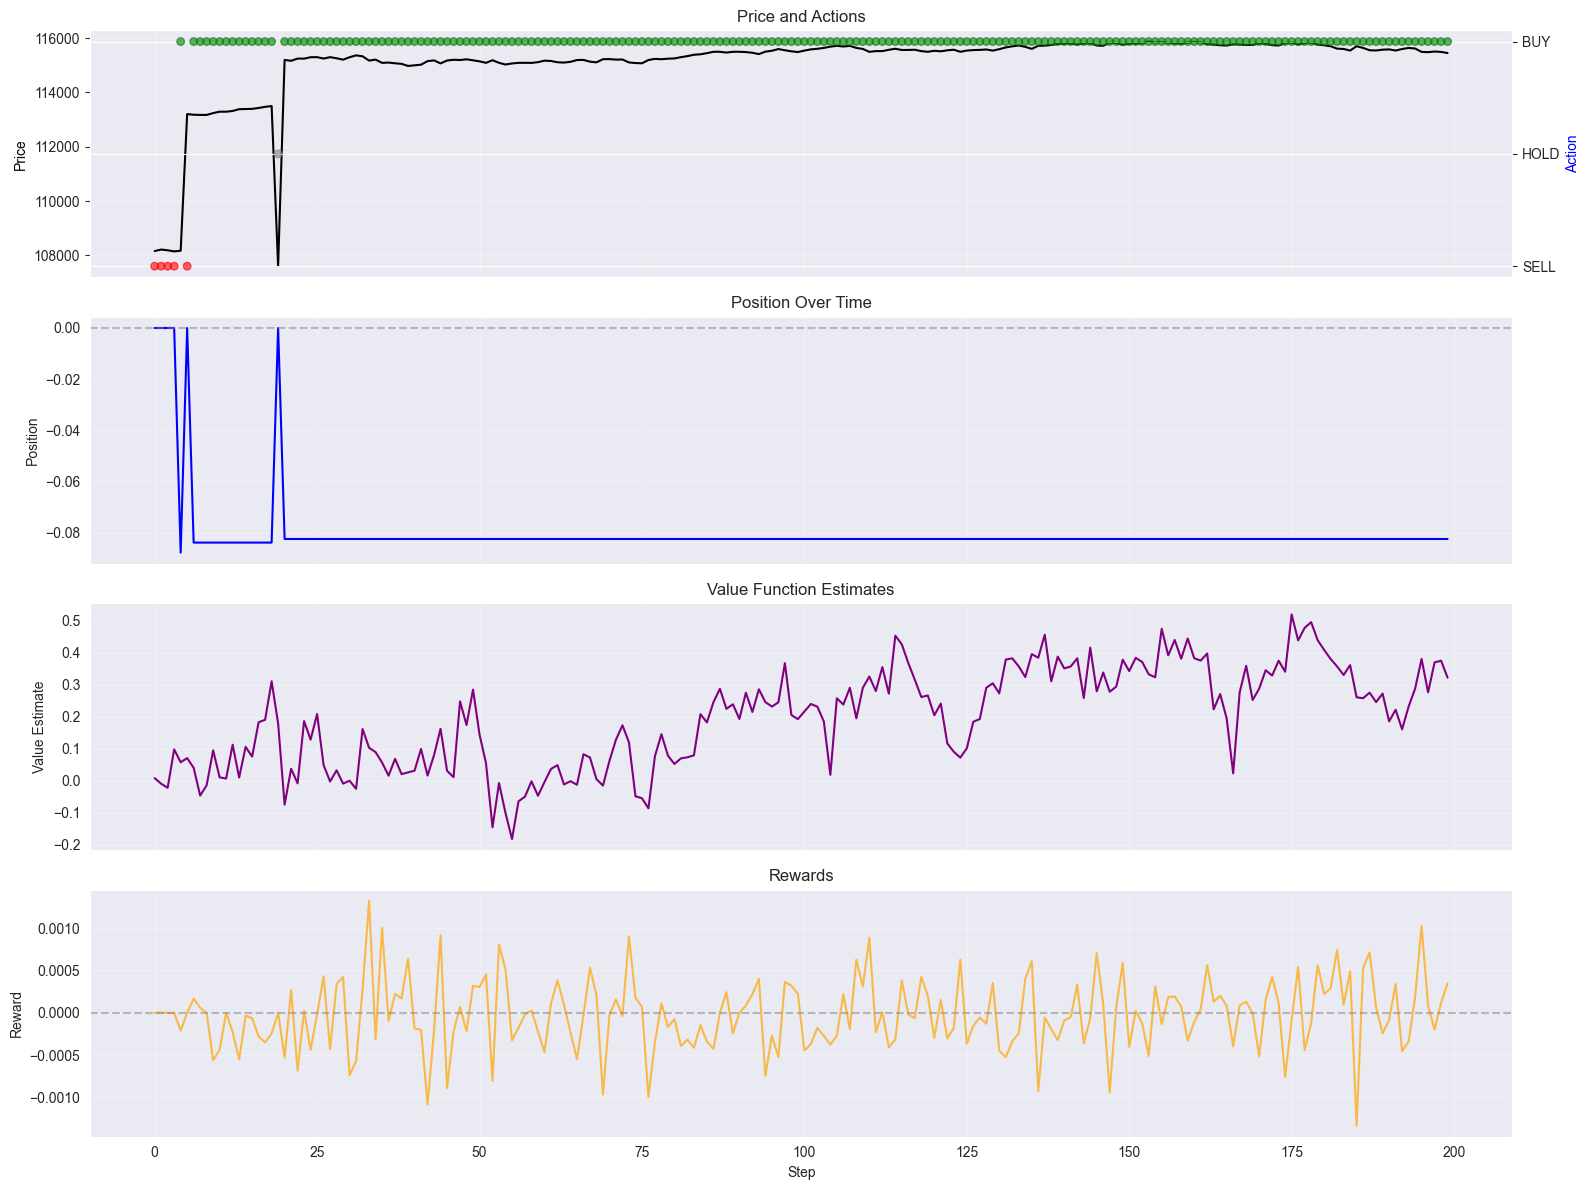

In [8]:
# Plot first 200 steps for detailed view
n_steps = min(200, len(train_results['actions']))

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

steps = np.arange(n_steps)

# Price and actions
ax = axes[0]
ax.plot(steps, train_results['prices'][:n_steps], label='Price', color='black', linewidth=1.5)
ax2 = ax.twinx()
colors = ['red' if a == 0 else 'gray' if a == 1 else 'green' 
          for a in train_results['actions'][:n_steps]]
ax2.scatter(steps, train_results['actions'][:n_steps], c=colors, alpha=0.6, s=30)
ax.set_ylabel('Price', color='black')
ax2.set_ylabel('Action', color='blue')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['SELL', 'HOLD', 'BUY'])
ax.set_title('Price and Actions')
ax.grid(True, alpha=0.3)

# Position
ax = axes[1]
ax.plot(steps, train_results['positions'][:n_steps], label='Position', color='blue')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Position')
ax.set_title('Position Over Time')
ax.grid(True, alpha=0.3)

# Value function
ax = axes[2]
ax.plot(steps, train_results['values'][:n_steps], label='Value', color='purple')
ax.set_ylabel('Value Estimate')
ax.set_title('Value Function Estimates')
ax.grid(True, alpha=0.3)

# Rewards
ax = axes[3]
ax.plot(steps, train_results['rewards'][:n_steps], label='Reward', color='orange', alpha=0.7)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Step')
ax.set_ylabel('Reward')
ax.set_title('Rewards')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Test on Validation Data


=== Validation Data Rollout ===
Episode 1: 5561 steps, return=0.0247
Episode 2: 5 steps, return=-0.0000
Episode 3: 7888 steps, return=0.0086
Episode 4: 51 steps, return=-0.0001
Episode 5: 1452 steps, return=0.0111
Episode 6: 5898 steps, return=0.0249
Episode 7: 7034 steps, return=0.0208
Episode 8: 5182 steps, return=0.0150
Episode 9: 10 steps, return=-0.0024
Episode 10: 5132 steps, return=0.0146


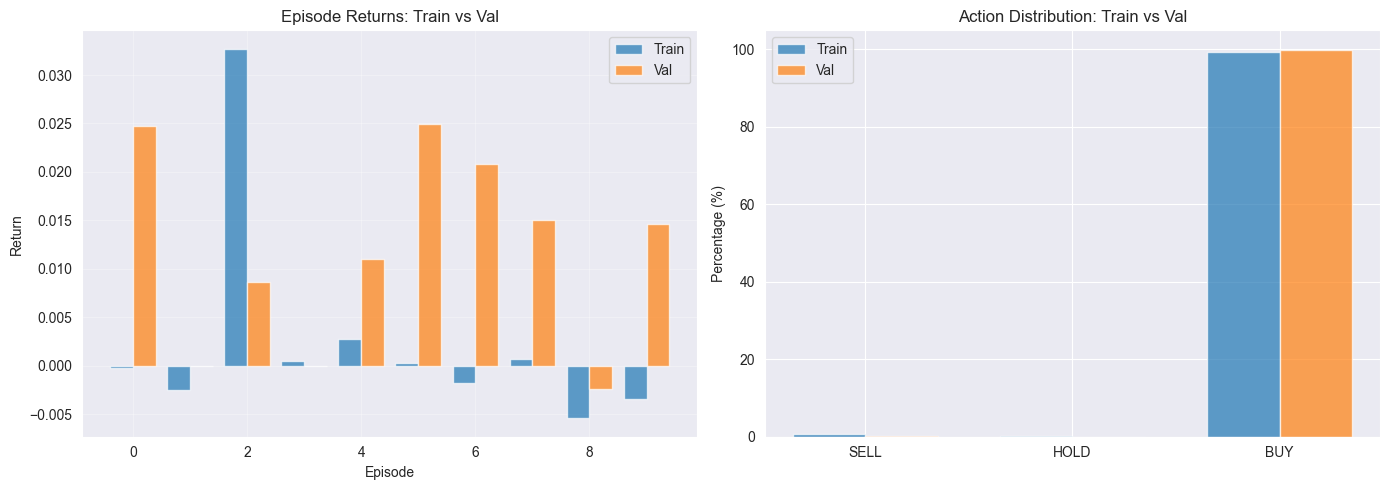


Validation Summary:
  Mean episode return: 0.0117
  Std episode return: 0.0097
  Mean value estimate: 0.1490


In [9]:
print("\n=== Validation Data Rollout ===")
val_results = rollout_policy(val_vec_env, model, n_episodes=10)

# Compare train vs val
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Episode returns comparison
ax = axes[0]
x = np.arange(len(train_results['episode_returns']))
ax.bar(x - 0.2, train_results['episode_returns'], width=0.4, label='Train', alpha=0.7)
ax.bar(x + 0.2, val_results['episode_returns'], width=0.4, label='Val', alpha=0.7)
ax.set_xlabel('Episode')
ax.set_ylabel('Return')
ax.set_title('Episode Returns: Train vs Val')
ax.legend()
ax.grid(True, alpha=0.3)

# Action distribution comparison
ax = axes[1]
train_action_pcts = np.bincount(train_results['actions'], minlength=3) / len(train_results['actions']) * 100
val_action_pcts = np.bincount(val_results['actions'], minlength=3) / len(val_results['actions']) * 100

x = np.arange(3)
width = 0.35
ax.bar(x - width/2, train_action_pcts, width, label='Train', alpha=0.7)
ax.bar(x + width/2, val_action_pcts, width, label='Val', alpha=0.7)
ax.set_ylabel('Percentage (%)')
ax.set_title('Action Distribution: Train vs Val')
ax.set_xticks(x)
ax.set_xticklabels(action_names)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nValidation Summary:")
print(f"  Mean episode return: {val_results['episode_returns'].mean():.4f}")
print(f"  Std episode return: {val_results['episode_returns'].std():.4f}")
print(f"  Mean value estimate: {val_results['values'].mean():.4f}")

## 8. Policy Heatmap: Action Probabilities

Getting action probabilities...


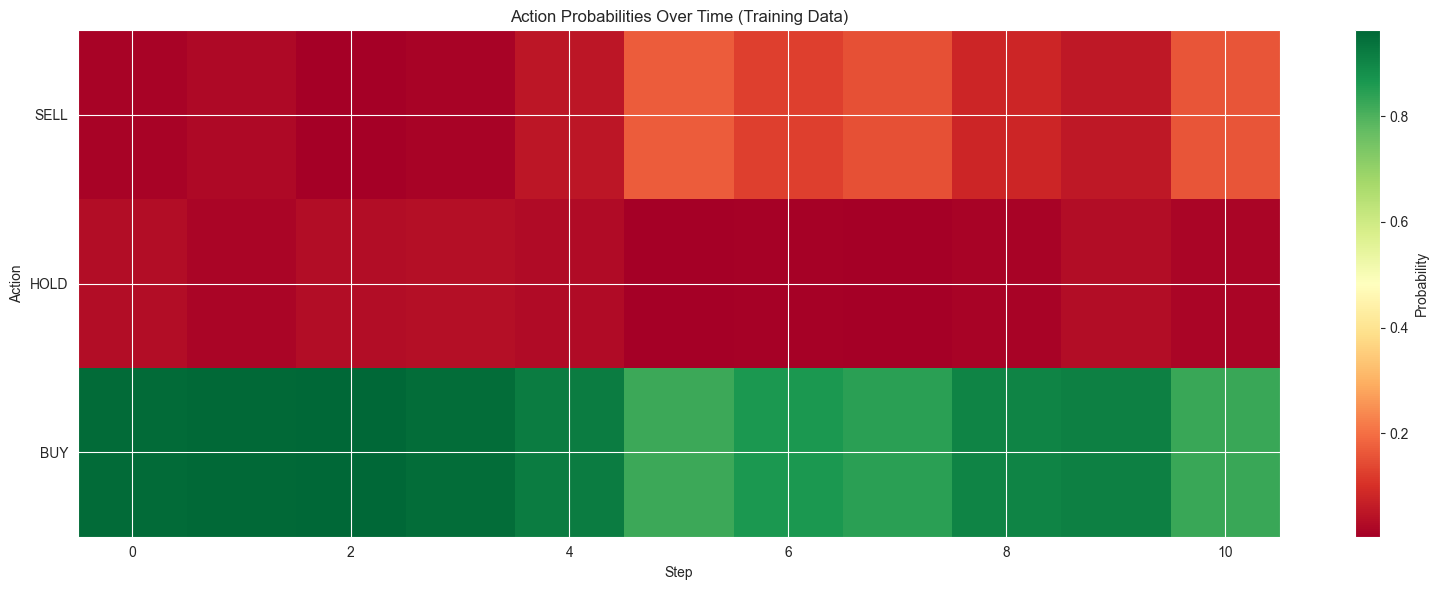


Mean entropy: 0.3405 (0=certain, 1.0986=uniform)


In [10]:
def get_action_probabilities(env, model, n_steps=100):
    """Get action probabilities for a rollout."""
    import warnings
    
    obs = env.reset()
    probs_list = []
    
    for _ in range(n_steps):
        # Get action probabilities
        obs_tensor = model.policy.obs_to_tensor(obs)[0]
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')
            distribution = model.policy.get_distribution(obs_tensor)
            probs = distribution.distribution.probs.detach().cpu().numpy()[0]
        
        probs_list.append(probs)
        
        # Take action
        action, _ = model.predict(obs, deterministic=False)
        obs, reward, done, info = env.step(action)
        
        if done[0]:
            break
    
    return np.array(probs_list)

print("Getting action probabilities...")
train_probs = get_action_probabilities(train_vec_env, model, n_steps=200)

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(train_probs.T, aspect='auto', cmap='RdYlGn', interpolation='nearest')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(action_names)
ax.set_xlabel('Step')
ax.set_ylabel('Action')
ax.set_title('Action Probabilities Over Time (Training Data)')
plt.colorbar(im, ax=ax, label='Probability')
plt.tight_layout()
plt.show()

# Show entropy (measure of uncertainty)
entropy = -np.sum(train_probs * np.log(train_probs + 1e-10), axis=1)
print(f"\nMean entropy: {entropy.mean():.4f} (0=certain, {np.log(3):.4f}=uniform)")

## 9. Summary and Insights

In [11]:
print("="*60)
print("POLICY ANALYSIS SUMMARY")
print("="*60)

print("\n1. TRAINING DATA PERFORMANCE")
print(f"   Mean Return: {train_results['episode_returns'].mean():.4f}")
print(f"   Std Return: {train_results['episode_returns'].std():.4f}")
print(f"   Action Distribution: SELL={train_action_pcts[0]:.1f}%, HOLD={train_action_pcts[1]:.1f}%, BUY={train_action_pcts[2]:.1f}%")

print("\n2. VALIDATION DATA PERFORMANCE")
print(f"   Mean Return: {val_results['episode_returns'].mean():.4f}")
print(f"   Std Return: {val_results['episode_returns'].std():.4f}")
print(f"   Action Distribution: SELL={val_action_pcts[0]:.1f}%, HOLD={val_action_pcts[1]:.1f}%, BUY={val_action_pcts[2]:.1f}%")

print("\n3. VALUE FUNCTION")
print(f"   Mean Value (Train): {train_results['values'].mean():.4f}")
print(f"   Std Value (Train): {train_results['values'].std():.4f}")
print(f"   Mean Value (Val): {val_results['values'].mean():.4f}")

print("\n4. POLICY CERTAINTY")
print(f"   Mean Entropy: {entropy.mean():.4f}")
print(f"   Max Entropy (uniform): {np.log(3):.4f}")
certainty = 1 - (entropy.mean() / np.log(3))
print(f"   Policy Certainty: {certainty*100:.1f}%")

print("\n" + "="*60)

POLICY ANALYSIS SUMMARY

1. TRAINING DATA PERFORMANCE
   Mean Return: 0.0024
   Std Return: 0.0104
   Action Distribution: SELL=0.6%, HOLD=0.2%, BUY=99.2%

2. VALIDATION DATA PERFORMANCE
   Mean Return: 0.0117
   Std Return: 0.0097
   Action Distribution: SELL=0.1%, HOLD=0.0%, BUY=99.9%

3. VALUE FUNCTION
   Mean Value (Train): -0.0391
   Std Value (Train): 0.1969
   Mean Value (Val): 0.1490

4. POLICY CERTAINTY
   Mean Entropy: 0.3405
   Max Entropy (uniform): 1.0986
   Policy Certainty: 69.0%

